Scratch cells for initial solenoid tests. Will probably become more sophisticated as time goes on.

# Setup

In [1]:
from g4beam import *
from scan import *
from cpymad.madx import Madx
import scipy

In [2]:
# Useful functions to handle multiple distributions
# Should probably be included in g4beam.py eventually

# Handle a distribution combining multiple z values
def combined_df_to_table(particles_df):
    res = list()
    for z, group in particles_df.groupby('z'):
        (x_emit, x_beta, _, x_alpha, x_d, x_Dd), (y_emit, y_beta, _, y_alpha, y_d, y_Dd), z_emit = calc_all_params(cut_outliers(group))
        res.append([z, x_emit, x_beta, x_alpha, x_d, x_Dd, y_emit, y_beta, y_alpha, y_d, y_Dd, z_emit, len(group)])
    res = pd.DataFrame(res, columns=["z", "x_emit", "x_beta", "x_alpha", "x_d", "x_Dd", "y_emit", "y_beta", "y_alpha", "y_d", "y_Dd", "z_emit", "N"])
    res.z *= 0.001
    return res

# Handle a list of distributions
def df_list_to_table(particles_list):
    z_list = [df.z[0] for df in particles_list]
    res = list()
    for z, df in zip(z_list, particles_list):
        (x_emit, x_beta, _, x_alpha, x_d, x_Dd), (y_emit, y_beta, _, y_alpha, y_d, y_Dd), z_emit = calc_all_params(cut_outliers(df))
        res.append([z, x_emit, x_beta, x_alpha, x_d, x_Dd, y_emit, y_beta, y_alpha, y_d, y_Dd, z_emit, len(df)])
    res = pd.DataFrame(res, columns=["z", "x_emit", "x_beta", "x_alpha", "x_d", "x_Dd", "y_emit", "y_beta", "y_alpha", "y_d", "y_Dd", "z_emit", "N"])
    res.z *= 0.001
    return res

# Show results from first test

Uses manually run results with a solenoid of thickness 175 mm and current 90 A/mm^2. Expected to form a beam waist at z=105.893 mm. Solenoids of lengths 1z (expected to bring beam to focus) and 2z (expected to bring beam to waist and then back again) were tested>

In [4]:
# Read a file that already exists (I generated by running manually)
df1 = read_trackfile("results/solenoid_tests/after_2z.txt")
test_data1 = combined_df_to_table(df1)
df2 = read_trackfile("results/solenoid_tests/after_1z.txt")
test_data2 = combined_df_to_table(df2)

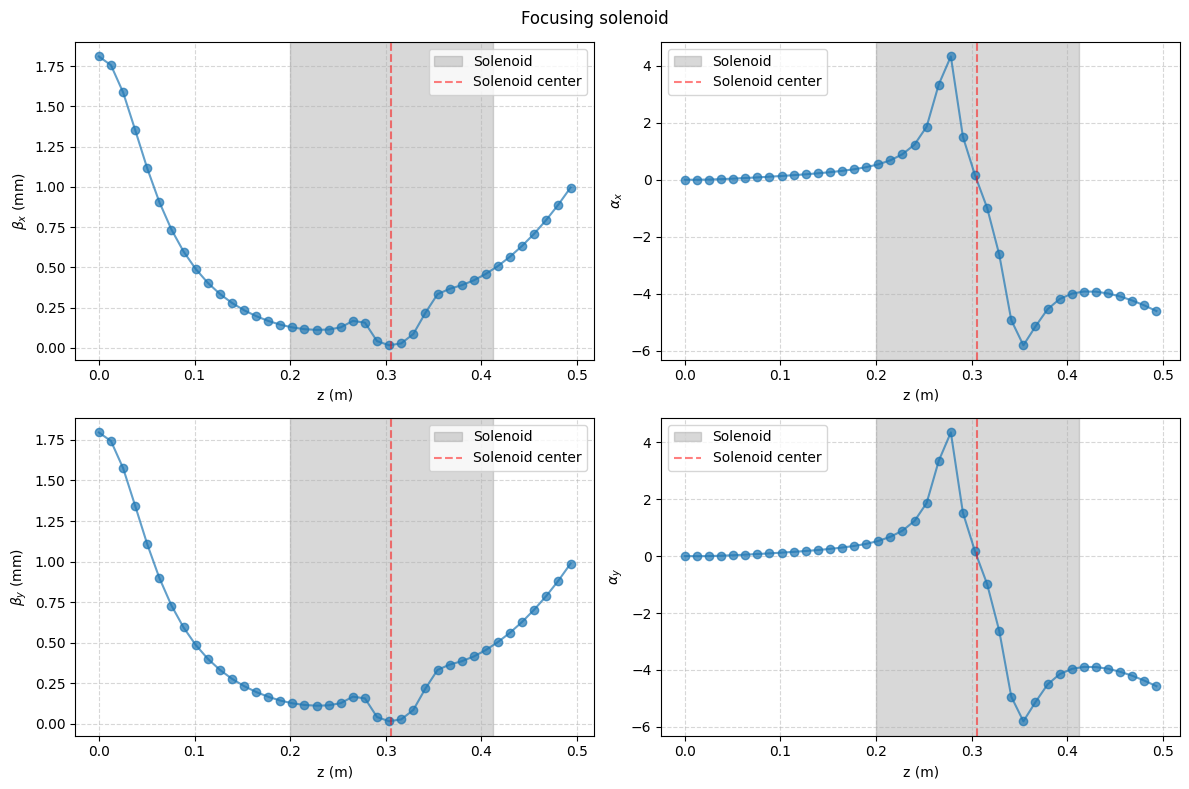

In [5]:
# Graph just the 1z case
columns = ["x_beta", "x_alpha", "y_beta", "y_alpha"]
column_names = [r"$\beta_x$ (mm)", r"$\alpha_x$", r"$\beta_y$ (mm)", r"$\alpha_y$"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Focusing solenoid")

start_offset=200 # mm
s_length=105.893 # mm

for ax, col, col_name in zip(axes.flat, columns, column_names):
    # ax.plot(test_data1["z"], test_data1[col], marker='o', linestyle='-', alpha=0.7, label="L=z solenoid", color='tab:blue')
    ax.plot(test_data2["z"], test_data2[col], marker='o', linestyle='-', alpha=0.7, color='tab:blue')
    ax.set_xlabel("z (m)")
    ax.set_ylabel(col_name)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axvspan(start_offset/1000, (start_offset+s_length*2)/1000, color='gray', alpha=0.3, label="Solenoid")
    ax.axvline((start_offset+s_length)/1000, color='red', alpha=0.5, linestyle="--", label="Solenoid center")
    # ax.axvline((start_offset)/1000, color='gray', alpha=0.5, linestyle="--", label="Solenoid start")
    # ax.axvline((start_offset+s_length)/1000, color='tab:blue', alpha=0.5, linestyle="--", label="z")
    # ax.axvline((start_offset+s_length*2)/1000, color='tab:orange', alpha=0.5, linestyle="--", label="2z")
    ax.legend()

plt.tight_layout()  # Adjust layout to fit title
# plt.savefig("visuals/2025/solenoid_multiple.png")
plt.show()

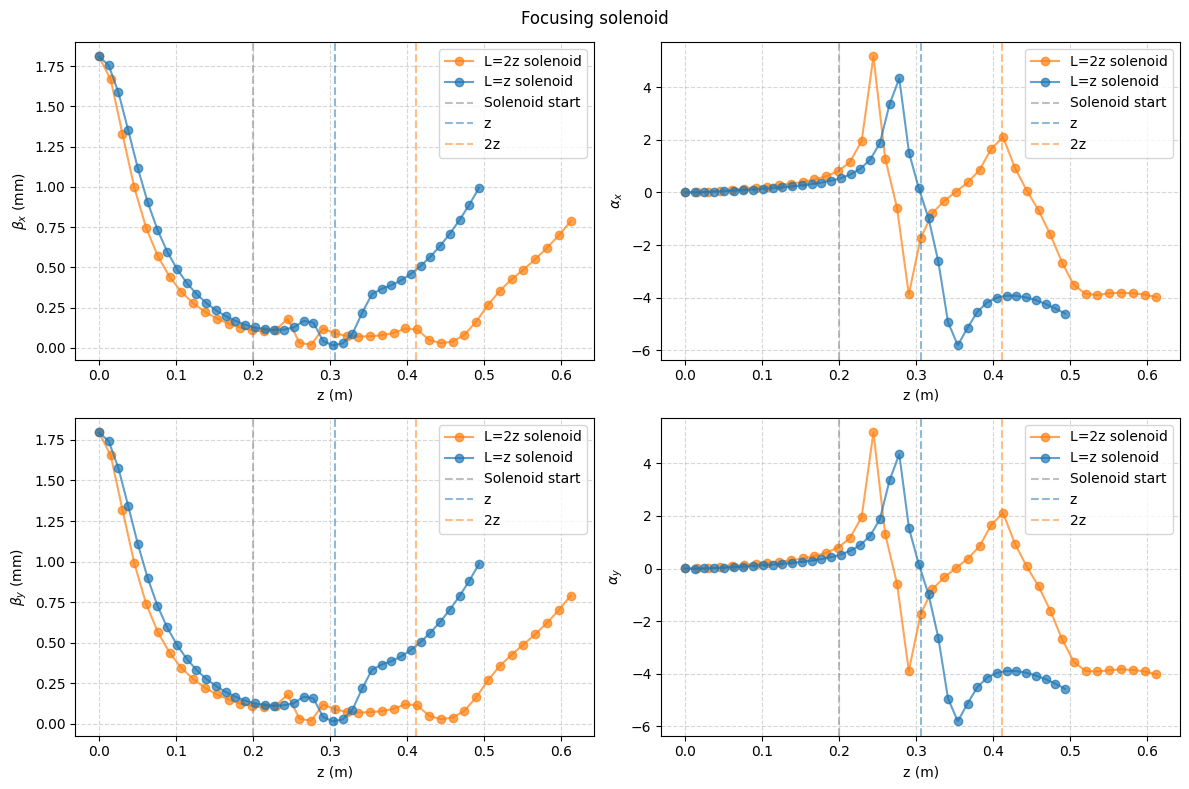

In [7]:
# Graph both cases
columns = ["x_beta", "x_alpha", "y_beta", "y_alpha"]
column_names = [r"$\beta_x$ (mm)", r"$\alpha_x$", r"$\beta_y$ (mm)", r"$\alpha_y$"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Focusing solenoid")

start_offset=200 # mm
s_length=105.893 # mm

for ax, col, col_name in zip(axes.flat, columns, column_names):
    ax.plot(test_data1["z"], test_data1[col], marker='o', linestyle='-', alpha=0.7, label="L=2z solenoid", color='tab:orange')
    ax.plot(test_data2["z"], test_data2[col], marker='o', linestyle='-', alpha=0.7, label="L=z solenoid", color='tab:blue')
    ax.set_xlabel("z (m)")
    ax.set_ylabel(col_name)
    ax.grid(True, linestyle='--', alpha=0.5)
    # ax.axvspan(start_offset/1000, (start_offset+s_length)/1000, color='gray', alpha=0.3, label="Solenoid")
    # ax.axvline((start_offset+s_length/2)/1000, color='red', alpha=0.5, linestyle="--", label="Solenoid center")
    ax.axvline((start_offset)/1000, color='gray', alpha=0.5, linestyle="--", label="Solenoid start")
    ax.axvline((start_offset+s_length)/1000, color='tab:blue', alpha=0.5, linestyle="--", label="z")
    ax.axvline((start_offset+s_length*2)/1000, color='tab:orange', alpha=0.5, linestyle="--", label="2z")
    ax.legend()

plt.tight_layout()  # Adjust layout to fit title
# plt.savefig("visuals/2025/solenoid_multiple.png")
plt.show()

# OLD: Generate and run distributions

Trying to figure out how to do this with combined output method

In [ ]:
# Generate a distribution and run it

t_emit = 0.145  # mm
momentum = 100  # MeV/c
beta_x = 1.8    # m
beta_y = 1.8    # m
alpha = 0     # dimensionless
l_emit = 1      # mm
pz_std = 0.8

particles_before = gen_distribution((beta_x, alpha, t_emit, 0, 0), (beta_y, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
# write_trackfile(particles_before, "solenoid_particles_before.txt")
particles_after = run_g4beam(particles_before, "G4_SolenoidTest.g4bl", maxStep=0.25)

In [12]:
test_data = combined_df_to_table(particles_after)

# OLD: Phase space plots throughout solenoid

I'm not generating these anymore because they're so long, but it could be useful as an example

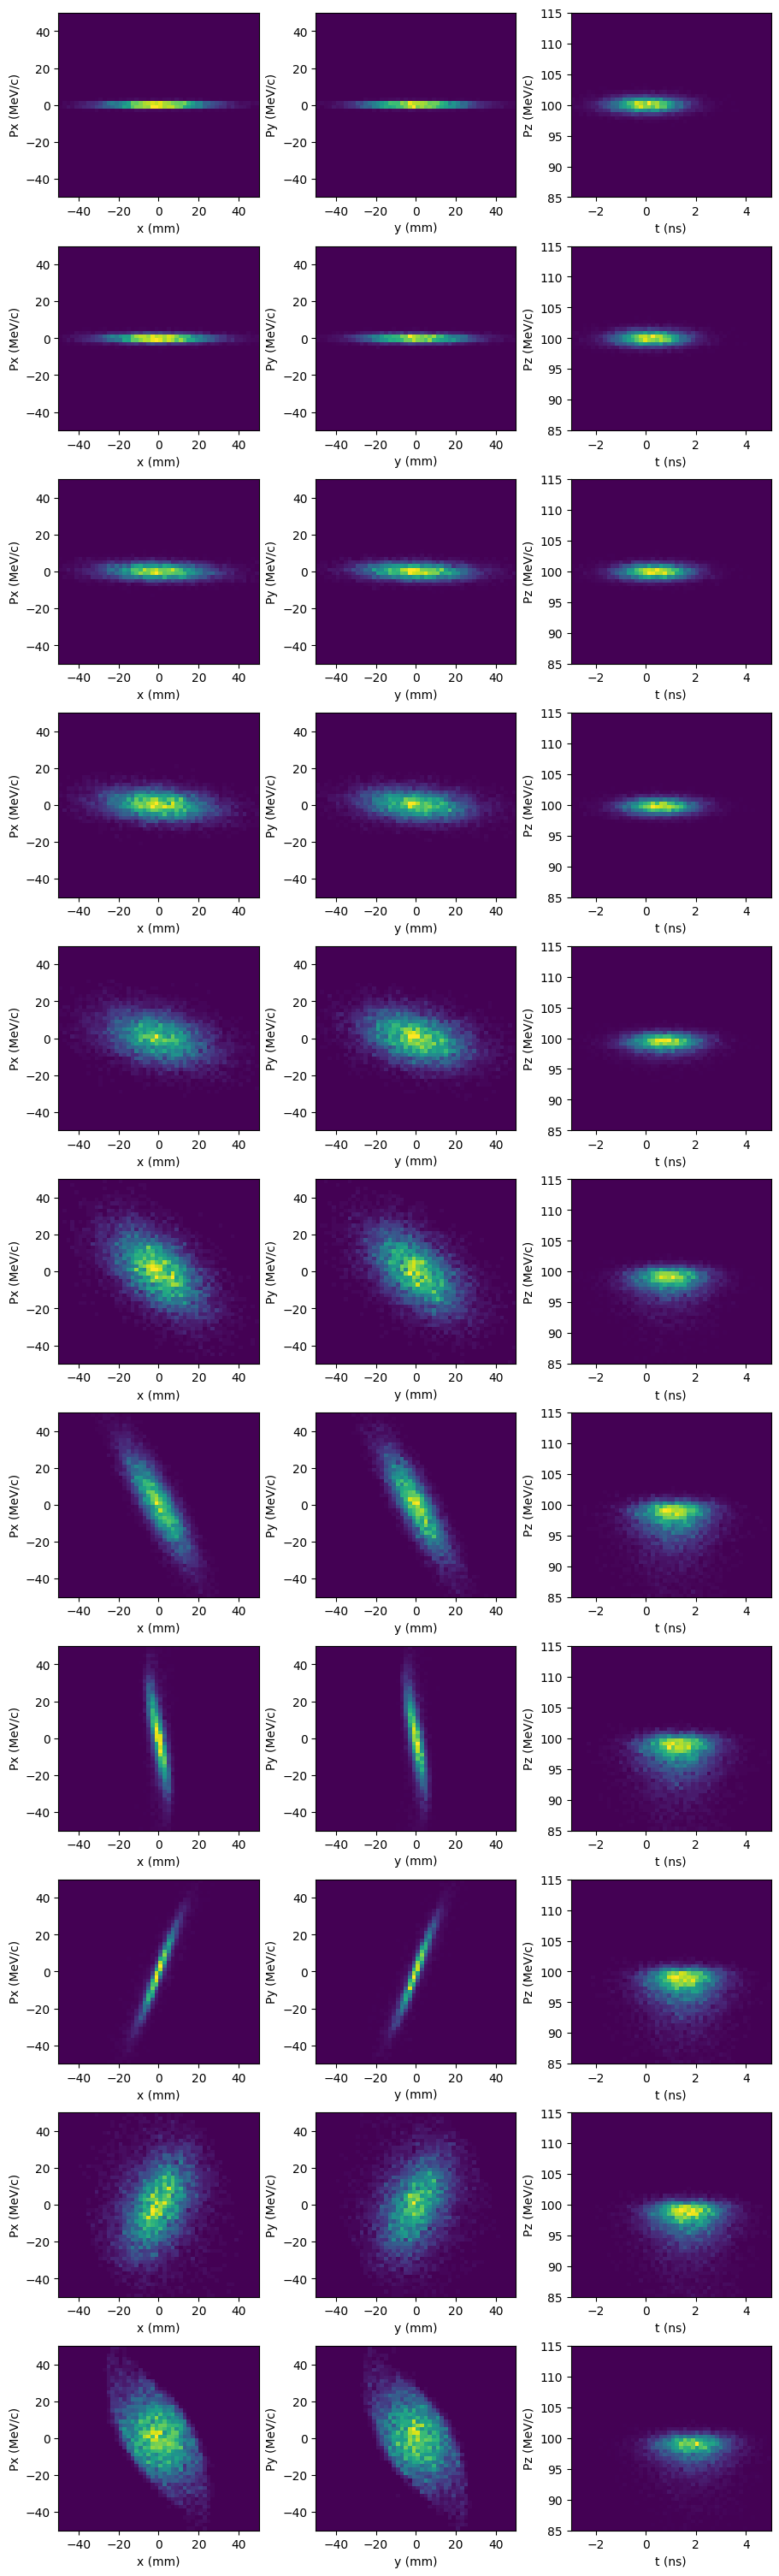

In [7]:
PLOT_TARGETS = particles_after_list[1:-1]
# PLOT_TITLES = [f"{i}" for i in range(10)]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-50, 50], [-50, 50]]
L_RANGES = [[-3, 5], [85, 115]]

fig, axes = plt.subplots(ncols = len(PLOT_AXES), nrows = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(9, 30)
for i, df in enumerate(PLOT_TARGETS):
    # axes[i][0].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[i][j]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

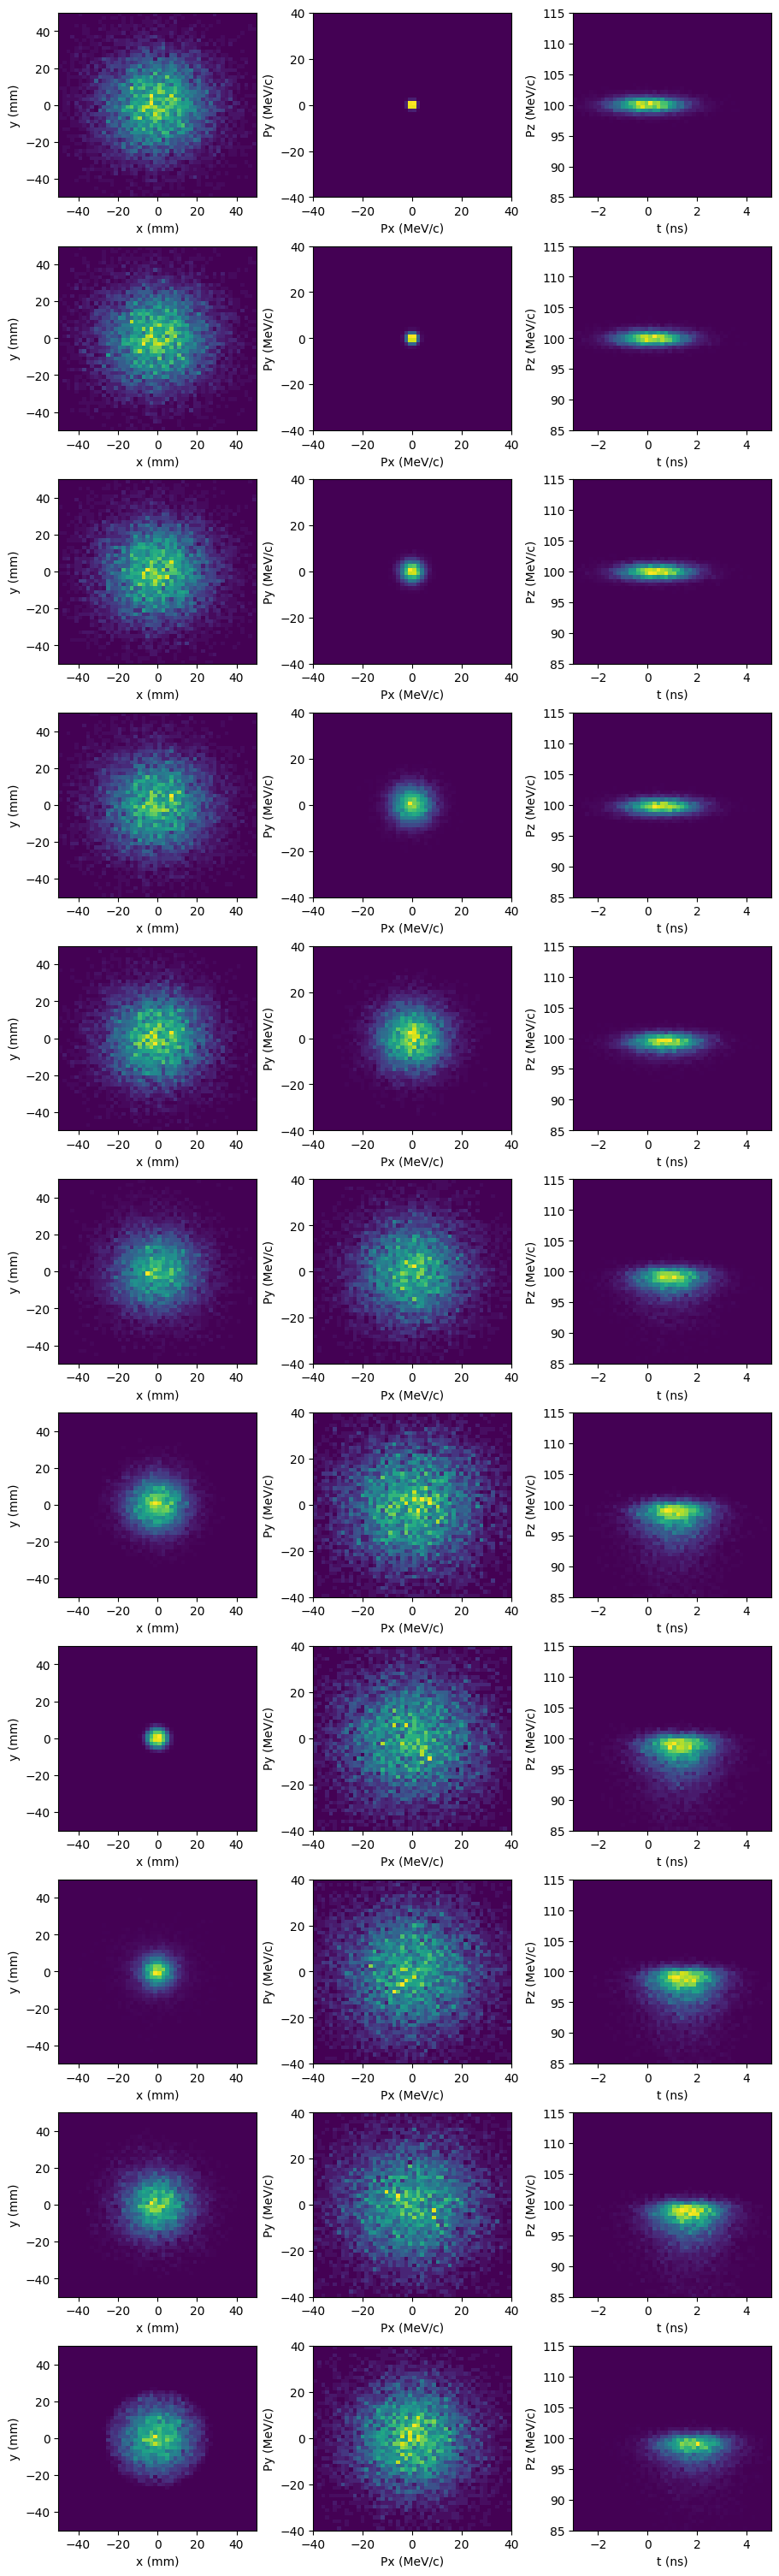

In [8]:
PLOT_TARGETS = particles_after_list[1:-1]
PLOT_AXES = [("x", "y"), ("Px", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "y (mm)"), ("Px (MeV/c)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
RANGES = [[[-50, 50], [-50, 50]], [[-40, 40], [-40, 40]], [[-3, 5], [85, 115]]]

fig, axes = plt.subplots(ncols = len(PLOT_AXES), nrows = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(9, 30)
for row, df in zip(axes, PLOT_TARGETS):
    for (xaxis, yaxis), (xlabel, ylabel), ax_ranges, ax in zip(PLOT_AXES, PLOT_LABELS, RANGES, row):
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=ax_ranges)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

# OLD: Calculations

Some attempts to do calculations in Python

In [3]:
# Store the vacuum permeability for convenience
# As all our lengths are in mm, we store it in units of T*mm/A
MU_0 = scipy.constants.physical_constants["vacuum mag. permeability"][0]*1000

# Reminder:
# magnetic field = solenoid thickness * current density * MU_0
# beam waist distance = 2*pi * momentum / (charge * magnetic field)